## Demo

In [10]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import torch
from synthnormaug.synthetic_intensity_augmentation import SyntheticGMMAugmentation

### load an example of a z-score normalized image, WMH mask and Synthseg image

In [11]:
flair = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_flair.nii.gz")))
wmh = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_wmh.nii.gz")))
synthseg = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_synthseg.nii.gz")))

In [12]:
data = {'FLAIR':flair, 'label':wmh, 'synthseg':synthseg}

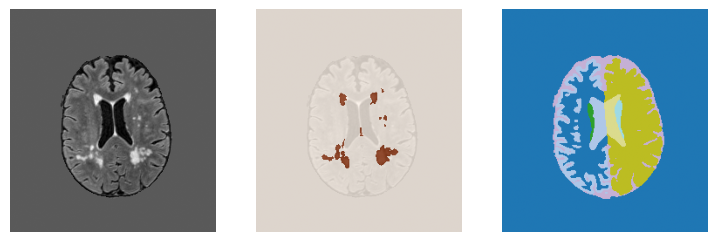

In [8]:
islice = 140
fig, axs = plt.subplots(1, 3, figsize=(9, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(wmh[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[2].imshow(synthseg[islice], origin='lower', cmap='tab20')
for ax in axs:
    ax.axis('off')

### example SynthNorm augmentation

In [24]:
from synthnormaug.synthetic_intensity_augmentation import SyntheticGMMAugmentation

In [25]:
gmm_weight_path = "synthnormaug/synthetic_intensity_augmentation/gmm_params"
synthnorm = SyntheticGMMAugmentation(
    mean_z_temperature_cap=10,
    std_z_temperature_cap=10,
    std_weighting=0.5,
    keys=['FLAIR'],
    wmh_mask='label',
    gmm_weight_path=gmm_weight_path
)

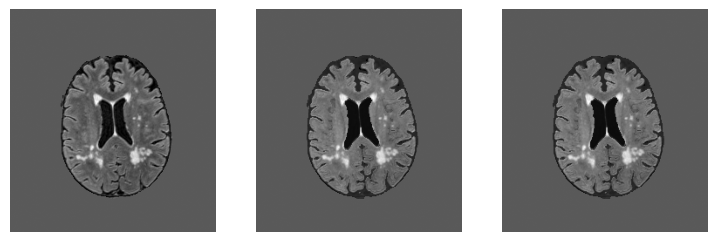

In [26]:
example_1 = synthnorm(data)
example_2 = synthnorm(data)

islice = 140
fig, axs = plt.subplots(1, 3, figsize=(9, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(example_1['FLAIR'][islice], origin='lower', cmap='gray')
axs[2].imshow(r['FLAIR'][islice], origin='lower', cmap='gray')

for ax in axs:
    ax.axis('off')

### example Perlin Bias Field

### example of full augmentation pipeline